# Group 10 Final Project: Dominating Set → Min-Sum Multicenter Transformation

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import itertools

In [116]:
# === Step 1: Load Graph from CSV ===
def load_graph_from_csv(filename):
    g = nx.Graph()
    with open(filename, 'r') as f:
        for line in f:
            nodes = line.strip().split(',')
            if len(nodes) == 2:
                g.add_edge(int(nodes[0]), int(nodes[1]))
            elif len(nodes) == 1:
                g.add_node(int(nodes[0]))
    return g

In [117]:
# === Step 2: Transform to Min-Sum Multicenter ===
def transform_dominating_to_minsum(g, k):
    g_prime = nx.Graph()
    nodes = list(g.nodes())
    for i, u in enumerate(nodes):
        for v in nodes[i+1:]:
            weight = 1 if g.has_edge(u, v) else 999
            g_prime.add_edge(u, v, weight=weight)
    b = len(g.nodes()) - k
    return g_prime, k, b

In [118]:
# === Step 3: Compute Multicenter Cost ===
def compute_min_sum(g_prime, centers):
    total = 0
    for v in g_prime.nodes():
        if v in centers:
            continue
        try:
            dists = [nx.shortest_path_length(g_prime, v, s, weight='weight') for s in centers]
            total += min(dists)
        except:
            total += 999
    return total

In [119]:
# === Step 4: Brute-force Best Centers ===
def find_best_centers(g_prime, k, b):
    if len(g_prime.nodes()) < k:
        print(f"Error: The number of nodes ({len(g_prime.nodes())}) is less than k ({k}).  No centers can be selected.")
        return None, float('inf')  # Return None and infinity to indicate failure

    best = None
    best_cost = float('inf')
    for centers in itertools.combinations(g_prime.nodes(), k):
        cost = compute_min_sum(g_prime, centers)
        if cost <= b and cost < best_cost:
            best = centers
            best_cost = cost
    return best, best_cost


In [120]:
# === Step 5: Dominating Set Verifier ===
def is_dominating_set(g, dom_set):
    for v in g.nodes():
        if v not in dom_set and not any(u in dom_set for u in g.neighbors(v)):
            return False
    return True

In [121]:
# === Step 6: Visualization ===
def visualize_graph(g, title, highlight_nodes=None):
    pos = nx.spring_layout(g, seed=42)
    plt.figure(figsize=(8, 6))
    node_colors = ['tomato' if highlight_nodes and node in highlight_nodes else 'skyblue' for node in g.nodes()]
    nx.draw(g, pos, with_labels=True, node_color=node_colors, edge_color='gray', node_size=500, font_size=10)
    plt.title(title)
    plt.axis('off')
    plt.show()

In [122]:
def visualize_transformed_graph_with_weights(g, title):
    pos = nx.spring_layout(g, seed=42)
    plt.figure(figsize=(8, 6))

    # Draw nodes
    nx.draw_networkx_nodes(g, pos, node_color='skyblue', node_size=600)

    # Draw edges and labels
    nx.draw_networkx_edges(g, pos, edge_color='black')
    edge_labels = {(u, v): '1' for u, v in g.edges()}
    nx.draw_networkx_edge_labels(g, pos, edge_labels=edge_labels, font_color='red', font_size=10, label_pos=0.4)

    # Draw node labels
    nx.draw_networkx_labels(g, pos, font_size=12)

    plt.title(title)
    plt.axis('off')
    plt.show()

In [123]:
# === Step 7: Reverse Transformation ===
def reverse_multicenter_to_ds(g_prime, centers, radius):
    sp = dict(nx.floyd_warshall(g_prime, weight='weight'))
    H = nx.Graph()
    H.add_nodes_from(g_prime.nodes())
    for u in g_prime.nodes():
        for v in g_prime.nodes():
            if u != v and sp[u][v] <= radius:
                H.add_edge(u, v)
    return H

In [142]:
# === Step 8: Main Execution ===
filename = "input_16 vertices.csv"
k = 6

In [143]:
# Load and transform
g = load_graph_from_csv(filename)
g_prime, k_prime, b = transform_dominating_to_minsum(g, k)

In [144]:
print(f"Number of nodes: {g.number_of_nodes()}")
print(f"Number of edges: {g.number_of_edges()}")
print(f"Trying to find a dominating set of size k = {k}")

Number of nodes: 16
Number of edges: 24
Trying to find a dominating set of size k = 6


In [145]:
# Adjacency list of G'
print("\n=== Adjacency List of Transformed Graph G′ ===")
for u in g_prime.nodes():
    neighbors = [v for v in g_prime.neighbors(u) if g_prime[u][v]['weight'] == 1]
    print(f"{u}: {neighbors}")


=== Adjacency List of Transformed Graph G′ ===
3: [4, 12, 5]
4: [3, 12, 5]
12: [3, 4, 15]
5: [3, 4, 15]
15: [12, 5, 8]
9: [11, 1, 13]
11: [9, 10, 7]
1: [9, 10, 2]
13: [9, 6, 0]
10: [11, 1, 2]
7: [11, 14, 0]
8: [15, 6, 14]
6: [13, 8, 2]
14: [7, 8, 0]
0: [13, 7, 14]
2: [1, 10, 6]


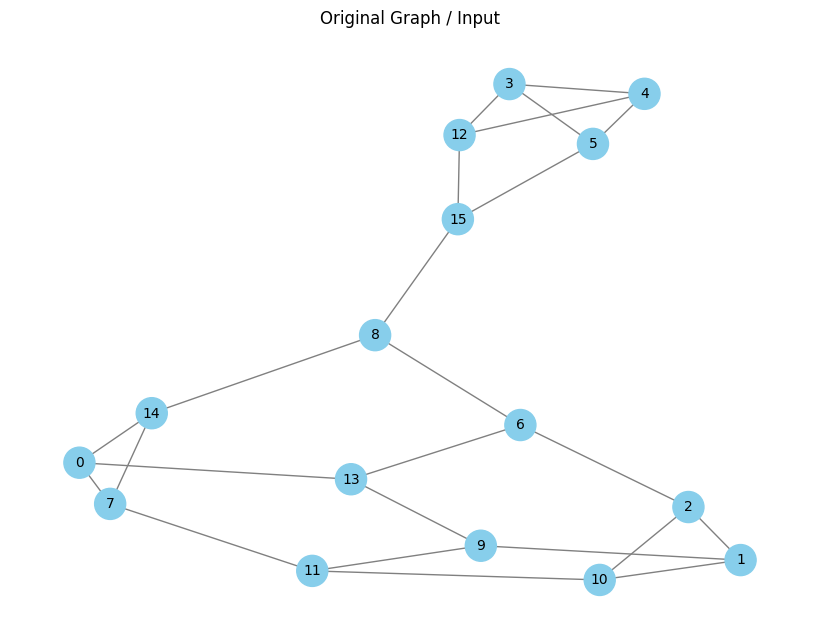

In [146]:
# Visuals
visualize_graph(g, "Original Graph / Input")

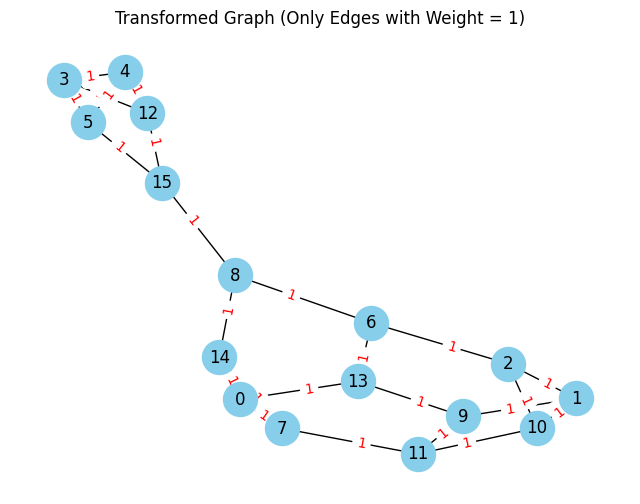

In [147]:
g_prime_filtered = nx.Graph()
for u, v, d in g_prime.edges(data=True):
    if d['weight'] == 1:
        g_prime_filtered.add_edge(u, v, weight=1)
g_prime_filtered.add_nodes_from(g_prime.nodes())

visualize_transformed_graph_with_weights(g_prime_filtered, "Transformed Graph (Only Edges with Weight = 1)")


In [148]:
# Solve
centers, cost = find_best_centers(g_prime, k, b)


=== Result ===
Selected Centers: (3, 4, 12, 9, 14, 2)
Total Min-Sum Distance: 10
Result: YES — dominating set exists
Verification: Valid Dominating Set


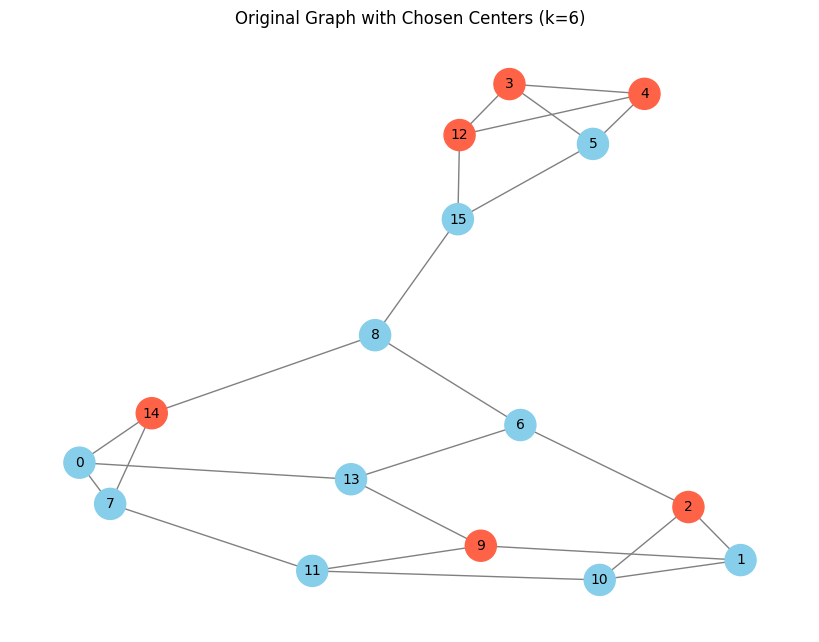

In [149]:
print("\n=== Result ===")
if centers:
    print(f"Selected Centers: {centers}")
    print(f"Total Min-Sum Distance: {cost}")
    print(f"Result: {'YES — dominating set exists' if cost <= b else 'NO — dominating set does not exist'}")
    print(f"Verification: {'Valid Dominating Set' if is_dominating_set(g, centers) else 'NOT a Dominating Set'}")
    visualize_graph(g, f"Original Graph with Chosen Centers (k={k})", highlight_nodes=centers)


=== Reverse Reduction (G′ → H) Adjacency List ===
3: [4, 12, 5]
4: [3, 12, 5]
12: [3, 4, 15]
5: [3, 4, 15]
15: [12, 5, 8]
9: [11, 1, 13]
11: [9, 10, 7]
1: [9, 10, 2]
13: [9, 6, 0]
10: [11, 1, 2]
7: [11, 14, 0]
8: [15, 6, 14]
6: [13, 8, 2]
14: [7, 8, 0]
0: [13, 7, 14]
2: [1, 10, 6]
Dominating Set in H from centers: [3, 4, 12, 9, 14, 2]


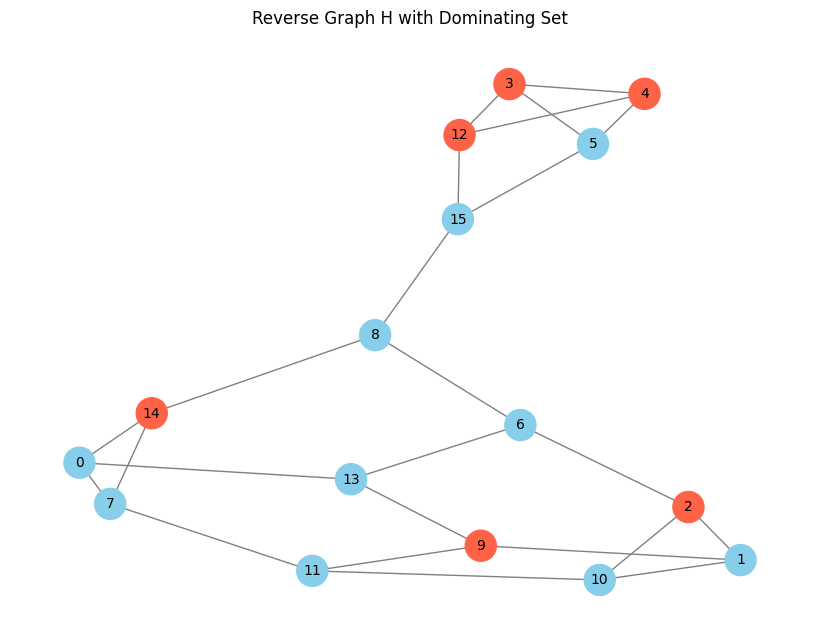

In [150]:
if centers:
    radius = max(
        min(nx.shortest_path_length(g_prime, v, s, weight='weight') for s in centers)
        for v in g_prime.nodes()
    )
    H = reverse_multicenter_to_ds(g_prime, centers, radius)
    print("\n=== Reverse Reduction (G′ → H) Adjacency List ===")
    for u in H.nodes():
        print(f"{u}: {list(H.neighbors(u))}")
    dom_set = [s for s in centers if all(any(nx.has_path(H, s, v) for s in centers) for v in H.nodes())]
    if dom_set:
        print(f"Dominating Set in H from centers: {dom_set}")
        visualize_graph(H, "Reverse Graph H with Dominating Set", highlight_nodes=dom_set)
    else:
        print("Could not form valid dominating set in reverse graph.")
else:
    print("No feasible set of centers found.")